# Exercitiul 1

1. We initialized the transposed convolutional layer by bilinear interpolation. Use Xavier initialization for the transposed convolutional layer and run the necessary experiment. How does the performance change?

In [ ]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from PIL import Image
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def read_voc_images(voc_dir, is_train=True):
    """Read all VOC feature and label images."""
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt')
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f:
        images = f.read().split()
    features, labels = [], []
    for i, fname in enumerate(images):
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass' ,f'{fname}.png'), mode))
    return features, labels

VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

def voc_colormap2label():
    """Build the mapping from RGB to class indices for VOC labels."""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

def voc_label_indices(colormap, colormap2label):
    """Map any RGB values in VOC labels to their class indices."""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]

def voc_rand_crop(feature, label, height, width):
    """Randomly crop both feature and label images."""
    rect = torchvision.transforms.RandomCrop.get_params(
        feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

class VOCSegDataset(torch.utils.data.Dataset):
    """A customized dataset to load the VOC dataset."""

    def __init__(self, is_train, crop_size, voc_dir):
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]

    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                       *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)

def load_data_voc(batch_size, crop_size):
    """Load the VOC semantic segmentation dataset."""
    voc_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar', os.path.join(
        'VOCdevkit', 'VOC2012'))
    num_workers = 2
    train_iter = torch.utils.data.DataLoader(
        VOCSegDataset(True, crop_size, voc_dir), batch_size,
        shuffle=True, drop_last=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(
        VOCSegDataset(False, crop_size, voc_dir), batch_size,
        drop_last=True, num_workers=num_workers)
    return train_iter, test_iter

def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor)
    weight = torch.zeros((in_channels, out_channels,
                          kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt
    return weight

pretrained_net = torchvision.models.resnet18(weights=torchvision.models.resnet.ResNet18_Weights.DEFAULT)

net = nn.Sequential(*list(pretrained_net.children())[:-2])

num_classes = 21
net.add_module('final_conv', nn.Conv2d(512, num_classes, kernel_size=1))
net.add_module('transpose_conv', nn.ConvTranspose2d(num_classes, num_classes,
                                    kernel_size=64, padding=16, stride=32))

# W = bilinear_kernel(num_classes, num_classes, 64)
# net.transpose_conv.weight.data.copy_(W);

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]


In [ ]:
nn.init.xavier_uniform_(net.transpose_conv.weight)

if net.transpose_conv.bias is not None:
    nn.init.zeros_(net.transpose_conv.bias)

In [ ]:
batch_size, crop_size = 32, (320, 480)
train_iter, test_iter = load_data_voc(batch_size, crop_size) #1 min

/tmp/ipython-input-1521458401.py:59: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  fp.extractall(base_dir)


read 1114 examples
read 1078 examples


In [ ]:
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = torch.argmax(y_hat, axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()  # Set the model to evaluation mode
        if not device:
            device = next(iter(net.parameters())).device
    # No. of correct predictions, no. of predictions
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X = X.to(device)
            y = y.to(device)
            total_hits += accuracy(net(X), y)
            total_samples += y.numel()
    return total_hits / total_samples * 100

def train_batch(net, X, y, loss, trainer, device):
    X = X.to(device)
    y = y.to(device)
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    train_loss_sum = l.sum()
    train_acc_sum = accuracy(pred, y)
    return train_loss_sum, train_acc_sum

def train(net, train_iter, test_iter, loss, trainer, num_epochs,
               device=try_gpu()):
    num_batches = len(train_iter)
    train_loss_all = []
    train_acc_all = []
    test_acc_all = []
    net = net.to(device)
    for epoch in range(num_epochs):
        # Sum of training loss, sum of training accuracy, no. of examples,
        # no. of predictions
        total_loss = 0
        total_acc = 0
        total_samples = 0
        total_predictions = 0
        for i, (features, labels) in enumerate(train_iter):
            l, acc = train_batch(
                net, features, labels, loss, trainer, device)
            total_loss += l
            total_acc += acc
            total_samples += labels.shape[0]
            total_predictions += labels.numel()
        train_loss_all.append(total_loss / total_samples)
        train_acc_all.append(total_acc / total_predictions * 100)
        test_acc = evaluate_accuracy(net, test_iter)
        test_acc_all.append(test_acc)
        print(f'loss {total_loss / total_samples:.3f}, train acc '
            f'{total_acc / total_predictions * 100:.3f}, test acc {test_acc:.3f}')
    return train_acc_all, test_acc_all

def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)

In [ ]:
num_epochs, lr, wd, device = 5, 0.001, 1e-3, try_gpu()
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)
train_acc_all, test_acc_all = train(net, train_iter, test_iter, loss, trainer, num_epochs, device) #6 min

loss 2.795, train acc 67.641, test acc 72.881
loss 2.328, train acc 72.787, test acc 72.894
loss 1.961, train acc 72.528, test acc 72.787
loss 1.696, train acc 72.678, test acc 72.901
loss 1.533, train acc 72.726, test acc 72.744


In [ ]:
def plot_accuracy(train_acc_all, test_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, test_acc_all, 'b', label='Test acc')
    plt.title('Training and test accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

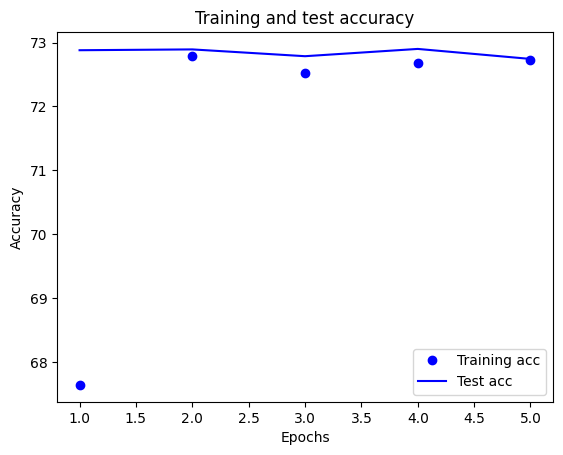

In [ ]:
plot_accuracy(train_acc_all, test_acc_all)

In [ ]:
def predict(img):
    X = test_iter.dataset.normalize_image(img).unsqueeze(0)
    pred = net(X.to(device)).argmax(dim=1)
    return pred.reshape(pred.shape[1], pred.shape[2])

In [ ]:
def label2image(pred):
    colormap = torch.tensor(VOC_COLORMAP, device=device)
    X = pred.long()
    return colormap[X, :]

/tmp/ipython-input-1521458401.py:59: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  fp.extractall(base_dir)


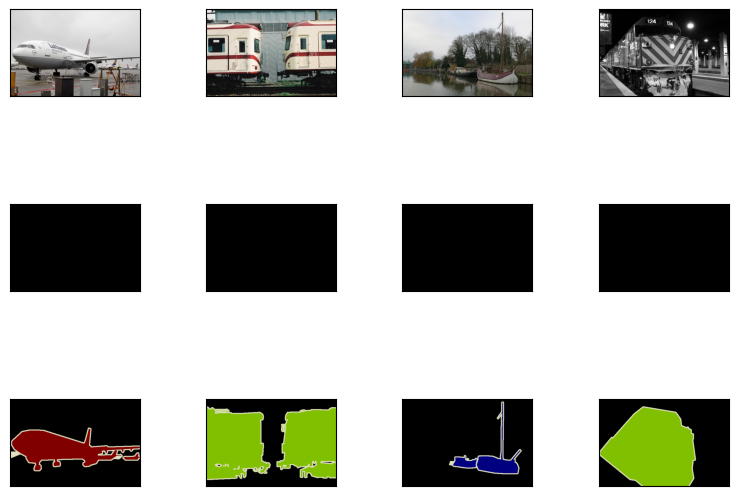

In [ ]:
voc_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar', 'VOCdevkit/VOC2012')
test_images, test_labels = read_voc_images(voc_dir, False)
n, imgs = 4, []
for i in range(n):
    crop_rect = (0, 0, 320, 480)
    X = torchvision.transforms.functional.crop(test_images[i], *crop_rect)
    pred = label2image(predict(X))
    imgs += [X.permute(1,2,0), pred.cpu(),
             torchvision.transforms.functional.crop(
                 test_labels[i], *crop_rect).permute(1,2,0)]
show_images(imgs[::3] + imgs[1::3] + imgs[2::3], 3, n, scale=2); #1 min

### Impactul Inițializării asupra Performanței FCN

**Schimbarea:**
Înlocuirea inițializării cu interpolare biliniară (Bilinear Interpolation) a stratului `ConvTranspose2d` cu inițializarea Xavier.

**Observații:**
1.  **Viteza de Convergență:** Modelul cu inițializare **Bilinear** converge mult mai rapid. Acest lucru se datorează faptului că stratul de upsampling acționează deja ca un algoritm clasic de redimensionare a imaginii, iar rețeaua trebuie doar să învețe ajustări fine ("delta-uri") pentru a corecta clasele. În schimb, cu inițializarea **Xavier**, stratul de upsampling pornește cu valori aleatoare, producând inițial doar zgomot, iar rețeaua trebuie să învețe procesul de upsampling de la zero.
2.  **Calitatea Segmentării (la puține epoci):** Într-un număr limitat de epoci (ex: 5-15), modelul cu Xavier va produce probabil segmentări foarte slabe, pixelate sau chiar o singură culoare predominantă, având un loss mult mai mare.
3.  **Concluzie:** Inițializarea biliniară acționează ca un "prior" puternic (cunoștințe anterioare despre structura spațială), fiind esențială pentru antrenarea eficientă a FCN-urilor atunci când resursele sau timpul sunt limitate.

In [ ]:
exit()

# Exercitiul 2

2. The original fully convolutional network paper also uses outputs of some intermediate CNN layers to construct the semantic segmentation, like in the figure below. We only implemented FCN-32s using the outputs of the last stage in ResNet-18 (corresponding to `pool5` in the figure below). Implement FCN-16s by using the outputs of the penultimate stage in the ResNet-18 network (corresponding to `pool4` in the figure below).

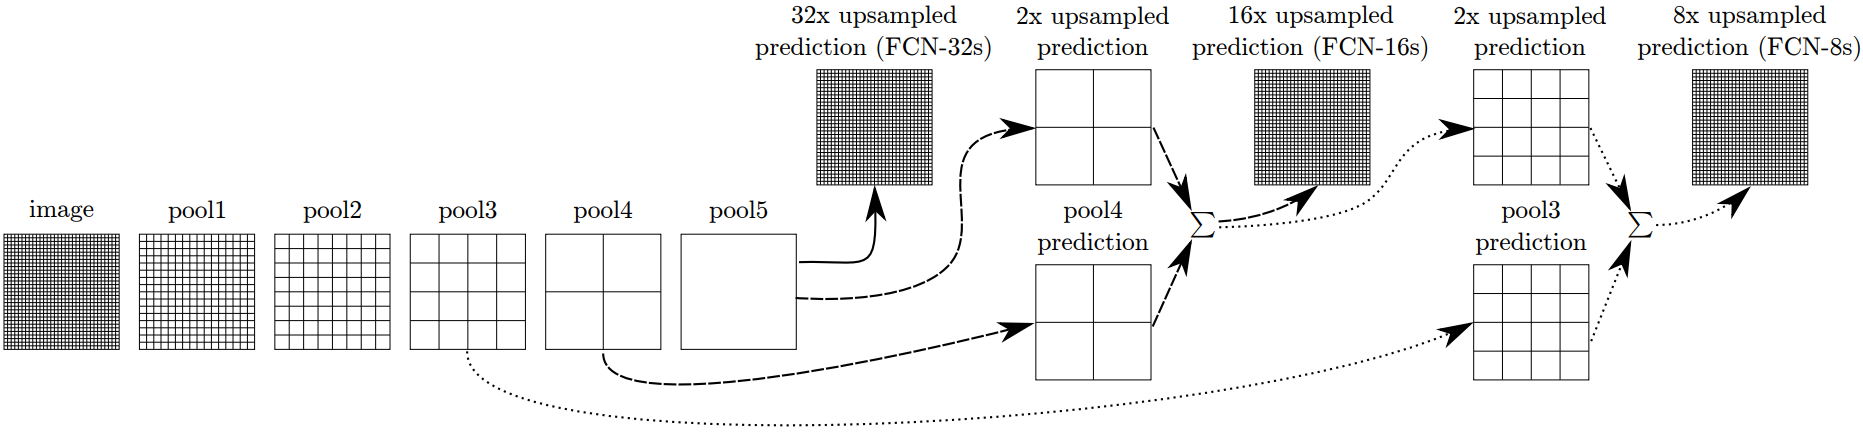

## V1

In [ ]:
# FCN-32s used children()[:-2] (removing layer4, avgpool, linear)
# FCN-16s should use children()[:-3] (removing layer4, avgpool, linear)
# to get the output before layer4, which is layer3 (pool4 stage).
list(pretrained_net.children())[-4:]

[Sequential(
   (0): BasicBlock(
     (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (downsample): Sequential(
       (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(2, 2), bias=False)
       (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     )
   )
   (1): BasicBlock(
     (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): Batc

In [ ]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from PIL import Image
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def read_voc_images(voc_dir, is_train=True):
    """Read all VOC feature and label images."""
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt')
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f:
        images = f.read().split()
    features, labels = [], []
    for i, fname in enumerate(images):
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass' ,f'{fname}.png'), mode))
    return features, labels

VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

def voc_colormap2label():
    """Build the mapping from RGB to class indices for VOC labels."""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

def voc_label_indices(colormap, colormap2label):
    """Map any RGB values in VOC labels to their class indices."""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]

def voc_rand_crop(feature, label, height, width):
    """Randomly crop both feature and label images."""
    rect = torchvision.transforms.RandomCrop.get_params(
        feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

class VOCSegDataset(torch.utils.data.Dataset):
    """A customized dataset to load the VOC dataset."""

    def __init__(self, is_train, crop_size, voc_dir):
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]

    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                       *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)

def load_data_voc(batch_size, crop_size):
    """Load the VOC semantic segmentation dataset."""
    voc_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar', os.path.join(
        'VOCdevkit', 'VOC2012'))
    num_workers = 2
    train_iter = torch.utils.data.DataLoader(
        VOCSegDataset(True, crop_size, voc_dir), batch_size,
        shuffle=True, drop_last=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(
        VOCSegDataset(False, crop_size, voc_dir), batch_size,
        drop_last=True, num_workers=num_workers)
    return train_iter, test_iter

def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor)
    weight = torch.zeros((in_channels, out_channels,
                          kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt
    return weight

pretrained_net = torchvision.models.resnet18(weights=torchvision.models.resnet.ResNet18_Weights.DEFAULT)

# For FCN-16s, we use the output of the penultimate stage (layer3) in ResNet-18.
# This means we exclude the last three modules: layer4, AdaptiveAvgPool2d, and Linear.
net = nn.Sequential(*list(pretrained_net.children())[:-3])

num_classes = 21
# The output of layer3 (for FCN-16s) has 256 channels
net.add_module('final_conv', nn.Conv2d(256, num_classes, kernel_size=1))
# For FCN-16s, the output is 1/16th the input size, so we need a stride of 16
# To get an output that is a factor of s larger than the input, with kernel 2s and padding s/2:
# New stride = 16, so kernel_size = 2 * 16 = 32, padding = 16 / 2 = 8
net.add_module('transpose_conv', nn.ConvTranspose2d(num_classes, num_classes,
                                    kernel_size=32, padding=8, stride=16))

# For FCN-16s, the kernel size for bilinear interpolation should also match the new kernel_size
W = bilinear_kernel(num_classes, num_classes, 32)
net.transpose_conv.weight.data.copy_(W);


In [ ]:
batch_size, crop_size = 32, (320, 480)
train_iter, test_iter = load_data_voc(batch_size, crop_size) #1 min

/tmp/ipython-input-3825280644.py:59: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  fp.extractall(base_dir)


read 1114 examples
read 1078 examples


In [ ]:
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = torch.argmax(y_hat, axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()  # Set the model to evaluation mode
        if not device:
            device = next(iter(net.parameters())).device
    # No. of correct predictions, no. of predictions
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X = X.to(device)
            y = y.to(device)
            total_hits += accuracy(net(X), y)
            total_samples += y.numel()
    return total_hits / total_samples * 100

def train_batch(net, X, y, loss, trainer, device):
    X = X.to(device)
    y = y.to(device)
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    train_loss_sum = l.sum()
    train_acc_sum = accuracy(pred, y)
    return train_loss_sum, train_acc_sum

def train(net, train_iter, test_iter, loss, trainer, num_epochs,
               device=try_gpu()):
    num_batches = len(train_iter)
    train_loss_all = []
    train_acc_all = []
    test_acc_all = []
    net = net.to(device)
    for epoch in range(num_epochs):
        # Sum of training loss, sum of training accuracy, no. of examples,
        # no. of predictions
        total_loss = 0
        total_acc = 0
        total_samples = 0
        total_predictions = 0
        for i, (features, labels) in enumerate(train_iter):
            l, acc = train_batch(
                net, features, labels, loss, trainer, device)
            total_loss += l
            total_acc += acc
            total_samples += labels.shape[0]
            total_predictions += labels.numel()
        train_loss_all.append(total_loss / total_samples)
        train_acc_all.append(total_acc / total_predictions * 100)
        test_acc = evaluate_accuracy(net, test_iter)
        test_acc_all.append(test_acc)
        print(f'loss {total_loss / total_samples:.3f}, train acc '
            f'{total_acc / total_predictions * 100:.3f}, test acc {test_acc:.3f}')
    return train_acc_all, test_acc_all

def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)

In [ ]:
num_epochs, lr, wd, device = 5, 0.001, 1e-3, try_gpu()
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)
train_acc_all, test_acc_all = train(net, train_iter, test_iter, loss, trainer, num_epochs, device) #6 min

loss 1.981, train acc 68.253, test acc 72.804
loss 1.352, train acc 72.847, test acc 72.845
loss 1.264, train acc 72.748, test acc 72.868
loss 1.211, train acc 72.663, test acc 72.830
loss 1.176, train acc 72.638, test acc 72.976


In [ ]:
def plot_accuracy(train_acc_all, test_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, test_acc_all, 'b', label='Test acc')
    plt.title('Training and test accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

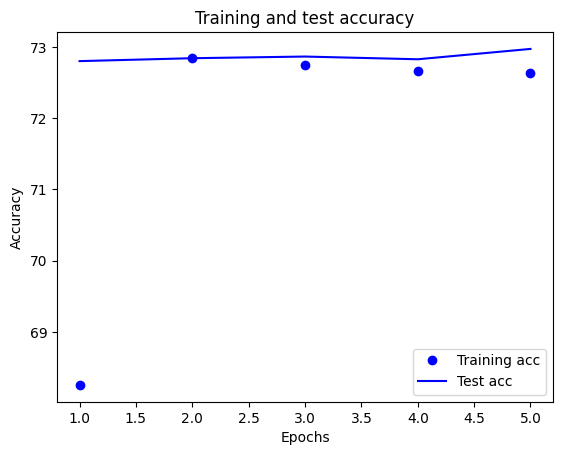

In [ ]:
plot_accuracy(train_acc_all, test_acc_all)

In [ ]:
def predict(img):
    X = test_iter.dataset.normalize_image(img).unsqueeze(0)
    pred = net(X.to(device)).argmax(dim=1)
    return pred.reshape(pred.shape[1], pred.shape[2])

In [ ]:
def label2image(pred):
    colormap = torch.tensor(VOC_COLORMAP, device=device)
    X = pred.long()
    return colormap[X, :]

/tmp/ipython-input-3825280644.py:59: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  fp.extractall(base_dir)


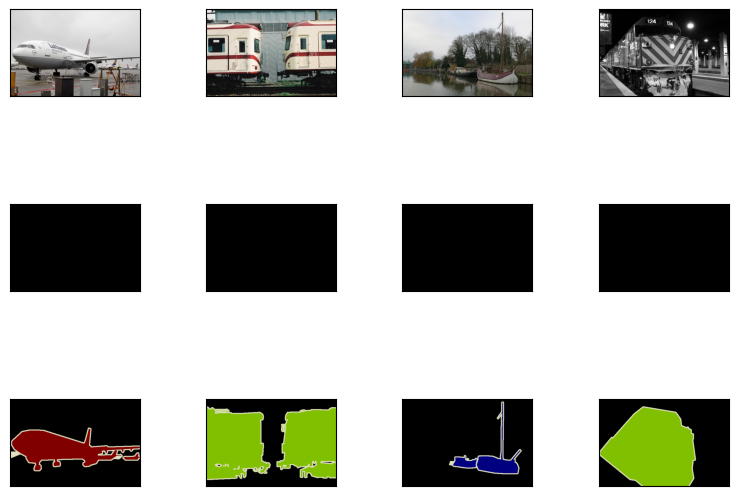

In [ ]:
voc_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar', 'VOCdevkit/VOC2012')
test_images, test_labels = read_voc_images(voc_dir, False)
n, imgs = 4, []
for i in range(n):
    crop_rect = (0, 0, 320, 480)
    X = torchvision.transforms.functional.crop(test_images[i], *crop_rect)
    pred = label2image(predict(X))
    imgs += [X.permute(1,2,0), pred.cpu(),
             torchvision.transforms.functional.crop(
                 test_labels[i], *crop_rect).permute(1,2,0)]
show_images(imgs[::3] + imgs[1::3] + imgs[2::3], 3, n, scale=2); #1 min

## V2 - ca la lab

In [3]:
pretrained_net = torchvision.models.resnet18(weights=torchvision.models.resnet.ResNet18_Weights.DEFAULT)
print("all resnet18 layers: \n\n")
list(pretrained_net.children())

all resnet18 layers: 




[Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False),
 BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True),
 ReLU(inplace=True),
 MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False),
 Sequential(
   (0): BasicBlock(
     (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   )
   (1): BasicBlock(
     (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), pad

In [4]:
list(pretrained_net.children())[-3] # layer 4 -> output 512

Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): BasicBlock(
    (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1

In [6]:
list(pretrained_net.children())[:-3] # totul panala layer3 inclusiv

[Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False),
 BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True),
 ReLU(inplace=True),
 MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False),
 Sequential(
   (0): BasicBlock(
     (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   )
   (1): BasicBlock(
     (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), pad

In [2]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from PIL import Image
from matplotlib import pyplot as plt
import os
import requests
import zipfile
import tarfile

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

def download(url, cache_dir=os.path.join('..', 'data')):
    """Download a file, return the local filename."""
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
        return fname
    print(f'Downloading {fname} from {url}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

def download_extract(url, folder=None):
    """Download and extract a zip file."""
    fname = download(url)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, 'Only zip/tar files can be extracted.'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def read_voc_images(voc_dir, is_train=True):
    """Read all VOC feature and label images."""
    txt_fname = os.path.join(voc_dir, 'ImageSets', 'Segmentation',
                             'train.txt' if is_train else 'val.txt')
    mode = torchvision.io.image.ImageReadMode.RGB
    with open(txt_fname, 'r') as f:
        images = f.read().split()
    features, labels = [], []
    for i, fname in enumerate(images):
        features.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'JPEGImages', f'{fname}.jpg')))
        labels.append(torchvision.io.read_image(os.path.join(
            voc_dir, 'SegmentationClass' ,f'{fname}.png'), mode))
    return features, labels

VOC_COLORMAP = [[0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
                [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
                [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
                [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
                [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
                [0, 64, 128]]

VOC_CLASSES = ['background', 'aeroplane', 'bicycle', 'bird', 'boat',
               'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
               'diningtable', 'dog', 'horse', 'motorbike', 'person',
               'potted plant', 'sheep', 'sofa', 'train', 'tv/monitor']

def voc_colormap2label():
    """Build the mapping from RGB to class indices for VOC labels."""
    colormap2label = torch.zeros(256 ** 3, dtype=torch.long)
    for i, colormap in enumerate(VOC_COLORMAP):
        colormap2label[
            (colormap[0] * 256 + colormap[1]) * 256 + colormap[2]] = i
    return colormap2label

def voc_label_indices(colormap, colormap2label):
    """Map any RGB values in VOC labels to their class indices."""
    colormap = colormap.permute(1, 2, 0).numpy().astype('int32')
    idx = ((colormap[:, :, 0] * 256 + colormap[:, :, 1]) * 256
           + colormap[:, :, 2])
    return colormap2label[idx]

def voc_rand_crop(feature, label, height, width):
    """Randomly crop both feature and label images."""
    rect = torchvision.transforms.RandomCrop.get_params(
        feature, (height, width))
    feature = torchvision.transforms.functional.crop(feature, *rect)
    label = torchvision.transforms.functional.crop(label, *rect)
    return feature, label

class VOCSegDataset(torch.utils.data.Dataset):
    """A customized dataset to load the VOC dataset."""

    def __init__(self, is_train, crop_size, voc_dir):
        self.transform = torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.crop_size = crop_size
        features, labels = read_voc_images(voc_dir, is_train=is_train)
        self.features = [self.normalize_image(feature)
                         for feature in self.filter(features)]
        self.labels = self.filter(labels)
        self.colormap2label = voc_colormap2label()
        print('read ' + str(len(self.features)) + ' examples')

    def normalize_image(self, img):
        return self.transform(img.float() / 255)

    def filter(self, imgs):
        return [img for img in imgs if (
            img.shape[1] >= self.crop_size[0] and
            img.shape[2] >= self.crop_size[1])]

    def __getitem__(self, idx):
        feature, label = voc_rand_crop(self.features[idx], self.labels[idx],
                                       *self.crop_size)
        return (feature, voc_label_indices(label, self.colormap2label))

    def __len__(self):
        return len(self.features)

def load_data_voc(batch_size, crop_size):
    """Load the VOC semantic segmentation dataset."""
    voc_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar', os.path.join(
        'VOCdevkit', 'VOC2012'))
    num_workers = 2
    train_iter = torch.utils.data.DataLoader(
        VOCSegDataset(True, crop_size, voc_dir), batch_size,
        shuffle=True, drop_last=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(
        VOCSegDataset(False, crop_size, voc_dir), batch_size,
        drop_last=True, num_workers=num_workers)
    return train_iter, test_iter

def bilinear_kernel(in_channels, out_channels, kernel_size):
    factor = (kernel_size + 1) // 2
    if kernel_size % 2 == 1:
        center = factor - 1
    else:
        center = factor - 0.5
    og = (torch.arange(kernel_size).reshape(-1, 1),
          torch.arange(kernel_size).reshape(1, -1))
    filt = (1 - torch.abs(og[0] - center) / factor) * \
           (1 - torch.abs(og[1] - center) / factor)
    weight = torch.zeros((in_channels, out_channels,
                          kernel_size, kernel_size))
    weight[range(in_channels), range(out_channels), :, :] = filt
    return weight



In [3]:
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = torch.argmax(y_hat, axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()  # Set the model to evaluation mode
        if not device:
            device = next(iter(net.parameters())).device
    # No. of correct predictions, no. of predictions
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            X = X.to(device)
            y = y.to(device)
            total_hits += accuracy(net(X), y)
            total_samples += y.numel()
    return total_hits / total_samples * 100

def train_batch(net, X, y, loss, trainer, device):
    X = X.to(device)
    y = y.to(device)
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    train_loss_sum = l.sum()
    train_acc_sum = accuracy(pred, y)
    return train_loss_sum, train_acc_sum

def train(net, train_iter, test_iter, loss, trainer, num_epochs,
               device=try_gpu()):
    num_batches = len(train_iter)
    train_loss_all = []
    train_acc_all = []
    test_acc_all = []
    net = net.to(device)
    for epoch in range(num_epochs):
        # Sum of training loss, sum of training accuracy, no. of examples,
        # no. of predictions
        total_loss = 0
        total_acc = 0
        total_samples = 0
        total_predictions = 0
        for i, (features, labels) in enumerate(train_iter):
            l, acc = train_batch(
                net, features, labels, loss, trainer, device)
            total_loss += l
            total_acc += acc
            total_samples += labels.shape[0]
            total_predictions += labels.numel()
        train_loss_all.append(total_loss / total_samples)
        train_acc_all.append(total_acc / total_predictions * 100)
        test_acc = evaluate_accuracy(net, test_iter)
        test_acc_all.append(test_acc)
        print(f'loss {total_loss / total_samples:.3f}, train acc '
            f'{total_acc / total_predictions * 100:.3f}, test acc {test_acc:.3f}')
    return train_acc_all, test_acc_all

def loss(inputs, targets):
    return F.cross_entropy(inputs, targets, reduction='none').mean(1).mean(1)

In [4]:
class FCN16(nn.Module):
  def __init__(self, num_classes = 21): # de ce 21? 20 de clase + background
    super().__init__()
    pretrained_net = torchvision.models.resnet18(weights=torchvision.models.resnet.ResNet18_Weights.DEFAULT)

    # de la input pana la layer3(pool4 echivalent)
    # Output-ul aici are stride 16 (dimensiunea imaginii / 16)
    # Copiii 0-6 sunt: conv1, bn1, relu, maxpool, layer1, layer2, layer3
    self.layer3 = nn.Sequential(*list(pretrained_net.children())[:-3])

    #layer4(Pool5 echivalent)
    # Output-ul aici are stride 32 (dimensiunea imaginii / 32)
    # Copilul 7 este layer4
    self.layer4 = list(pretrained_net.children())[-3]

    # --- Scorurile (Conv 1x1) ---
    # ResNet18 layer4 are 512 canale, layer3 are 256 canale
    self.score_32 = nn.Conv2d(512, num_classes, kernel_size=1)
    self.score_16 = nn.Conv2d(256, num_classes, kernel_size=1)

    # --- Upsampling layers ---

    # 1. Upsampling 2x pentru a aduce output-ul 32s la dimensiunea 16s
    self.upsample_x2 = nn.ConvTranspose2d(
        num_classes, num_classes, kernel_size = 4, padding = 1, stride = 2
    )

    # 2. Upsampling 16x pentru a aduce rezultatul combinat la dimensiunea originală
    self.upsample_x16 = nn.ConvTranspose2d(
        num_classes, num_classes, kernel_size = 32, padding = 8, stride = 16
        )

    self.init_weights(num_classes)

  def init_weights(self, num_classes):
    W1 = bilinear_kernel(num_classes, num_classes, 4)
    W2 = bilinear_kernel(num_classes, num_classes, 32)

    self.upsample_x2.weight.data.copy_(W1)
    self.upsample_x16.weight.data.copy_(W2)

  def forward(self, x):
    # 1. Trecem prin prima parte a rețelei
    feat16 = self.layer3(x) # Output shape: [N, 256, H/16, W/16]

    # 2. Trecem prin layer 4
    feat32 = self.layer4(feat16) # Output shape: [N, 512, H/32, W/32]

    # 3. Calculăm scorurile (reducem la 21 clase)
    s32 = self.score_32(feat32) # [N, 21, H/32, W/32]
    s16 = self.score_16(feat16) # [N, 21, H/16, W/16]

    # 4. Upsample la s32 cu 2x pentru a ajunge la dimensiunea lui s16
    upsampled_s32 = self.upsample_x2(s32) # [N, 21, H/16, W/16]

    # 5. Adunăm (Skip Connection)
    combined = upsampled_s32 + s16

    # 6. Upsample final la dimensiunea imaginii
    out = self.upsample_x16(combined) # [N, 21, H, W]

    return out

In [ ]:
class FCN16s(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        pretrained_net = torchvision.models.resnet18(weights=torchvision.models.resnet.ResNet18_Weights.DEFAULT)
        self.conv_block1 = nn.Sequential(*list(pretrained_net.children())[:6])
        self.conv_block3 = pretrained_net.layer3
        self.conv_block4 = pretrained_net.layer4

        self.conv_1x1_l4 = nn.Conv2d(512, num_classes, kernel_size=1)
        self.conv_1x1_l3 = nn.Conv2d(256, num_classes, kernel_size=1)

        self.upsample_2x = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=4, padding=1, stride=2)
        self.upsample_16x = nn.ConvTranspose2d(num_classes, num_classes, kernel_size=32, padding=8, stride=16)

        self.upsample_2x.weight.data.copy_(bilinear_kernel(num_classes, num_classes, 4))
        self.upsample_16x.weight.data.copy_(bilinear_kernel(num_classes, num_classes, 32))

    def forward(self, X):
        output1 = self.conv_block1(X)
        output3 = self.conv_block3(output1)
        output4 = self.conv_block4(output3)
        score_l4 = self.conv_1x1_l4(output4)
        score_l3 = self.conv_1x1_l3(output3)

        upsampled_score_l4 = self.upsample_2x(score_l4)
        combined_features = upsampled_score_l4 + score_l3

        final_output = self.upsample_16x(combined_features)

        return final_output


In [5]:
from torch.optim import optimizer
net = FCN16(num_classes=21)

optimizer = torch.optim.SGD(net.parameters(), lr=0.01, momentum=0.9)


nn.init.xavier_uniform_(net.score_32.weight)
nn.init.xavier_uniform_(net.score_16.weight)

Parameter containing:
tensor([[[[ 0.0200]],

         [[-0.0439]],

         [[-0.0830]],

         ...,

         [[-0.1288]],

         [[ 0.0044]],

         [[ 0.0188]]],


        [[[ 0.0226]],

         [[ 0.0128]],

         [[-0.0024]],

         ...,

         [[ 0.0711]],

         [[ 0.1021]],

         [[ 0.1369]]],


        [[[-0.0065]],

         [[-0.0222]],

         [[ 0.1047]],

         ...,

         [[-0.1371]],

         [[-0.1358]],

         [[ 0.1124]]],


        ...,


        [[[-0.0869]],

         [[-0.0234]],

         [[-0.0051]],

         ...,

         [[-0.1455]],

         [[-0.1394]],

         [[-0.0499]]],


        [[[ 0.0720]],

         [[-0.0447]],

         [[ 0.0385]],

         ...,

         [[-0.1189]],

         [[-0.1414]],

         [[ 0.0568]]],


        [[[-0.1075]],

         [[-0.0669]],

         [[-0.1117]],

         ...,

         [[-0.0733]],

         [[ 0.1316]],

         [[ 0.0201]]]], requires_grad=True)

In [6]:
batch_size, crop_size = 32, (320, 480)
train_iter, test_iter = load_data_voc(batch_size, crop_size) #1 min

/tmp/ipython-input-992620886.py:59: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  fp.extractall(base_dir)


read 1114 examples
read 1078 examples


In [7]:
num_epochs, lr, wd, device = 5, 0.001, 1e-3, try_gpu()
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)
train_acc_all, test_acc_all = train(net, train_iter, test_iter, loss, trainer, num_epochs, device) #6 min

loss 1.148, train acc 74.740, test acc 81.595
loss 0.565, train acc 83.693, test acc 82.824
loss 0.478, train acc 85.550, test acc 83.722
loss 0.406, train acc 87.236, test acc 84.406
loss 0.365, train acc 88.389, test acc 84.417


In [8]:
def plot_accuracy(train_acc_all, test_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, 'bo', label='Training acc')
    plt.plot(epochs, test_acc_all, 'b', label='Test acc')
    plt.title('Training and test accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

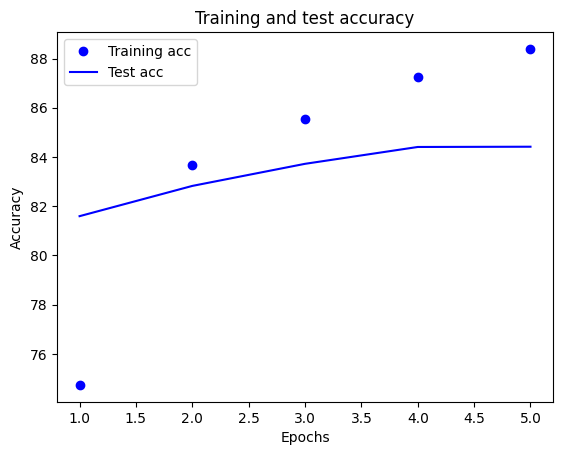

In [9]:
plot_accuracy(train_acc_all, test_acc_all)

In [10]:
def predict(img):
    X = test_iter.dataset.normalize_image(img).unsqueeze(0)
    pred = net(X.to(device)).argmax(dim=1)
    return pred.reshape(pred.shape[1], pred.shape[2])

In [11]:
def label2image(pred):
    colormap = torch.tensor(VOC_COLORMAP, device=device)
    X = pred.long()
    return colormap[X, :]

/tmp/ipython-input-992620886.py:59: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  fp.extractall(base_dir)


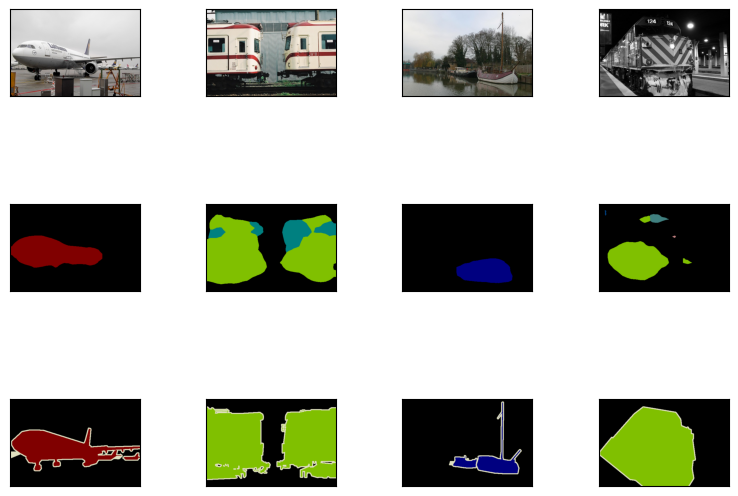

In [12]:
voc_dir = download_extract('http://d2l-data.s3-accelerate.amazonaws.com/VOCtrainval_11-May-2012.tar', 'VOCdevkit/VOC2012')
test_images, test_labels = read_voc_images(voc_dir, False)
n, imgs = 4, []
for i in range(n):
    crop_rect = (0, 0, 320, 480)
    X = torchvision.transforms.functional.crop(test_images[i], *crop_rect)
    pred = label2image(predict(X))
    imgs += [X.permute(1,2,0), pred.cpu(),
             torchvision.transforms.functional.crop(
                 test_labels[i], *crop_rect).permute(1,2,0)]
show_images(imgs[::3] + imgs[1::3] + imgs[2::3], 3, n, scale=2); #1 min

## Cum intelegi RESNET-18

In [13]:
import torchvision
import torch.nn as nn

# 1. Încărcăm modelul brut
resnet18 = torchvision.models.resnet18()

# 2. Vedem ce "copii" (blocuri principale) are
children = list(resnet18.children())

# 3. Printăm lista numerotată ca să vedem indicii
for i, child in enumerate(children):
    # Printăm doar tipul layer-ului pentru claritate (nu tot conținutul)
    print(f"Index {i}: {child._get_name()}")

Index 0: Conv2d
Index 1: BatchNorm2d
Index 2: ReLU
Index 3: MaxPool2d
Index 4: Sequential
Index 5: Sequential
Index 6: Sequential
Index 7: Sequential
Index 8: AdaptiveAvgPool2d
Index 9: Linear


In [14]:
import torch

# Creăm un tensor fals de dimensiune (Batch=1, Canale=3, H=224, W=224)
dummy_input = torch.zeros(1, 3, 224, 224)

# Luăm partea de rețea până la Layer 3
part1 = nn.Sequential(*list(resnet18.children())[:-3])
out1 = part1(dummy_input)
print(f"Output după Layer 3: {out1.shape}")
# Va afișa: [1, 256, 14, 14] -> DECI AVEM 256 CANALE (Stride 16: 224/14 = 16)

# Luăm doar Layer 4
part2 = list(resnet18.children())[-3]
out2 = part2(out1)
print(f"Output după Layer 4: {out2.shape}")
# Va afișa: [1, 512, 7, 7] -> DECI AVEM 512 CANALE (Stride 32: 224/7 = 32)

Output după Layer 3: torch.Size([1, 256, 14, 14])
Output după Layer 4: torch.Size([1, 512, 7, 7])


# Ghid de Supraviețuire: Implementarea FCN-16s în PyTorch

## 1. Cum identifici layerele corecte dintr-un model pre-antrenat?
Nu ghici indicii listei! Urmează acești pași de "inspecție":

* **Pasul 1:** Încarcă modelul brut și transformă-l în listă.
    ```python
    backbone = torchvision.models.resnet18()
    layers = list(backbone.children())
    ```
* **Pasul 2:** Printează lungimea și numele.
    ResNet-18 are de obicei 10 elemente principale.
    * Elementele 0-3: Procesare inițială (Conv1, BN, ReLU, MaxPool).
    * Elementele 4-7: Blocurile reziduale (Layer1...Layer4).
    * Elementele 8-9: Clasificare (AvgPool, FC) -> **Acestea se aruncă la segmentare!**
* **Pasul 3:** Selectează pe baza Stride-ului (cât de mult scade rezoluția).
    * Pentru **FCN-16s**, ai nevoie de output-ul unde imaginea e de 16x mai mică (`layer3` - index 6) și 32x mai mică (`layer4` - index 7).
    * De aceea folosim `[:-3]` (până la index 6 inclusiv) și `[-3]` (indexul 7).

## 2. Regula de Aur a Dimensiunilor (Dummy Input)
Înainte să scrii clasa finală, verifică numărul de canale rulând un tensor fals prin bucățile tăiate.

```python
# Exemplu de debugging
dummy_x = torch.randn(1, 3, 224, 224)
part1 = nn.Sequential(*list(resnet18.children())[:-3])
print(part1(dummy_x).shape)
# Dacă vezi [1, 256, 14, 14] -> Știi sigur că Score Layer trebuie să aibă in_channels=256.

In [16]:
backbone = torchvision.models.resnet18()
layers = list(backbone.children())
layers

[Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False),
 BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True),
 ReLU(inplace=True),
 MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False),
 Sequential(
   (0): BasicBlock(
     (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   )
   (1): BasicBlock(
     (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), pad

In [17]:
# Exemplu de debugging
dummy_x = torch.randn(1, 3, 224, 224)
part1 = nn.Sequential(*list(resnet18.children())[:-3])
print(part1(dummy_x).shape)
# Dacă vezi [1, 256, 14, 14] -> Știi sigur că Score Layer trebuie să aibă in_channels=256

torch.Size([1, 256, 14, 14])
